# Mapping of Los Angeles Citation Violation Data with GeoPandas

In [162]:
# Import data science packages
import pandas as pd
import numpy as np
import datetime
import re
import random
# Import visualization and geoanalytics packages
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from shapely.geometry import box
import pyproj
pd.set_option('display.max_rows', 100)

In [2]:
# https://data.lacity.org/A-Livable-and-Sustainable-City/LADOT-Metered-Parking-Inventory-Policies/s49e-q6j2
dg = pd.read_csv('LADOT_Metered_Parking_Inventory___Policies.csv')
dg.columns

Index(['SpaceID', 'BlockFace', 'MeterType', 'RateType', 'RateRange',
       'MeteredTimeLimit', 'ParkingPolicy', 'StreetCleaning', 'LatLng'],
      dtype='object')

In [3]:
dg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33989 entries, 0 to 33988
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   SpaceID           33989 non-null  object
 1   BlockFace         33989 non-null  object
 2   MeterType         33989 non-null  object
 3   RateType          33989 non-null  object
 4   RateRange         33989 non-null  object
 5   MeteredTimeLimit  33989 non-null  object
 6   ParkingPolicy     33989 non-null  object
 7   StreetCleaning    9614 non-null   object
 8   LatLng            33989 non-null  object
dtypes: object(9)
memory usage: 2.3+ MB


In [4]:
dg.head()

,SpaceID,BlockFace,MeterType,RateType,RateRange,MeteredTimeLimit,ParkingPolicy,StreetCleaning,LatLng
0,WU150,501 UNION DR,Single-Space,FLAT,$1.00,2HR,8A-6P Mon-Sat,12P-3P Mon,"(34.057219, -118.268751)"
1,MV161,12200 VENICE BL,Single-Space,FLAT,$1.00,2HR,8A-8P Mon-Sat,NaN,"(34.0043, -118.432007)"
2,ER138,2000 COLORADO BL,Single-Space,FLAT,$1.00,2HR,8A-8P Mon-Sat,NaN,"(34.139067, -118.210994)"
3,BF66,7901 BEVERLY BL,Single-Space,FLAT,$1.00,2HR,"8A-8P Mon-Sat, 11A-8P Sun",NaN,"(34.076203, -118.362266)"
4,CB121,1301 S HOPE ST,Single-Space,TOD,$1 - $2,4HR,8A-8P Mon-Sat,NaN,"(34.038863, -118.26618)"


In [5]:
def LatLng_convert(data):
    pair = []
    for coord in re.sub(r'[\(\),]', '', data).split(' '):
        pair.append(float(coord))
    return pair
dg['LatLng'] = dg.LatLng.apply(LatLng_convert)

In [6]:
dg.head()

,SpaceID,BlockFace,MeterType,RateType,RateRange,MeteredTimeLimit,ParkingPolicy,StreetCleaning,LatLng
0,WU150,501 UNION DR,Single-Space,FLAT,$1.00,2HR,8A-6P Mon-Sat,12P-3P Mon,"[34.057219, -118.268751]"
1,MV161,12200 VENICE BL,Single-Space,FLAT,$1.00,2HR,8A-8P Mon-Sat,NaN,"[34.0043, -118.432007]"
2,ER138,2000 COLORADO BL,Single-Space,FLAT,$1.00,2HR,8A-8P Mon-Sat,NaN,"[34.139067, -118.210994]"
3,BF66,7901 BEVERLY BL,Single-Space,FLAT,$1.00,2HR,"8A-8P Mon-Sat, 11A-8P Sun",NaN,"[34.076203, -118.362266]"
4,CB121,1301 S HOPE ST,Single-Space,TOD,$1 - $2,4HR,8A-8P Mon-Sat,NaN,"[34.038863, -118.26618]"


In [7]:
# Turn citation coordinates into Geopandas geometry column
geometry = [Point(xy) for xy in zip(dg.LatLng.apply(lambda x: x[1]), dg.LatLng.apply(lambda x: x[0]))]
crs = {'init': 'epsg:4326'}
geo_dg = gpd.GeoDataFrame(dg, crs=crs, geometry=geometry)

In [8]:
geo_dg

,SpaceID,BlockFace,MeterType,RateType,RateRange,MeteredTimeLimit,ParkingPolicy,StreetCleaning,LatLng,geometry
0,WU150,501 UNION DR,Single-Space,FLAT,$1.00,2HR,8A-6P Mon-Sat,12P-3P Mon,"[34.057219, -118.268751]",POINT (-118.26875 34.05722)
1,MV161,12200 VENICE BL,Single-Space,FLAT,$1.00,2HR,8A-8P Mon-Sat,NaN,"[34.0043, -118.432007]",POINT (-118.43201 34.00430)
2,ER138,2000 COLORADO BL,Single-Space,FLAT,$1.00,2HR,8A-8P Mon-Sat,NaN,"[34.139067, -118.210994]",POINT (-118.21099 34.13907)
3,BF66,7901 BEVERLY BL,Single-Space,FLAT,$1.00,2HR,"8A-8P Mon-Sat, 11A-8P Sun",NaN,"[34.076203, -118.362266]",POINT (-118.36227 34.07620)
4,CB121,1301 S HOPE ST,Single-Space,TOD,$1 - $2,4HR,8A-8P Mon-Sat,NaN,"[34.038863, -118.26618]",POINT (-118.26618 34.03886)
...,...,...,...,...,...,...,...,...,...,...
33984,SP522,300 7TH ST,Single-Space,FLAT,$0.50,2HR,8A-6P Mon-Sat,4A-630A Thu,"[33.737913, -118.285211]",POINT (-118.28521 33.73791)
33985,CP150,7101 OWENSMOUTH AV,Single-Space,FLAT,$1.00,2HR,8A-8P Mon-Sat,NaN,"[34.200583, -118.601673]",POINT (-118.60167 34.20058)
33986,CT299,901 N. HILL ST,Single-Space,TOD,$0.5 - $3,2HR,TANS 7A-9A Mon-Fri | PKG 9A-8P Mon-Sat,4A-630A Thu,"[34.066378, -118.237841]",POINT (-118.23784 34.06638)
33987,MM123,700 DETROIT ST,Single-Space,FLAT,$1.00,2HR,8A-8P Mon-Sat,9A-11A Mon,"[34.06164, -118.345289]",POINT (-118.34529 34.06164)


In [95]:
df = pd.read_csv('Parking_Citations.csv', usecols = 
                 ['Issue Date', 'Issue time', 'Meter Id', 'Location', 'Violation Description', 'Latitude', 'Longitude'])

In [96]:
df.columns = ['Issue_Date', 'Issue_Time', 'Meter ID','Location', 'Violation_Description', 'Latitude', 'Longitude']

In [97]:
df.describe()

,Issue_Time,Latitude,Longitude
count,1.042031e+07,1.042446e+07,1.042446e+07
mean,1.195929e+03,5.529417e+06,1.594255e+06
std,4.740662e+02,2.875818e+06,1.904020e+06
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.080000e+02,6.421887e+06,1.822195e+06
50%,1.152000e+03,6.451992e+06,1.841971e+06
75%,1.504000e+03,6.475222e+06,1.858206e+06
max,2.359000e+03,4.042322e+09,4.042322e+09


In [94]:
df[df.Issue_Date.str.contains('2019')]

,Issue_Date,Issue_Time,Meter ID,Location,Violation_Description,Latitude,Longitude,Datetime,Hour,Weekday
0,2019/09/17,0817,NaN,1324 84TH PL W,NO PARK/STREET CLEAN,6.471017e+06,1.808559e+06,2019-09-17 08:17:00,8,Tuesday
2,2019/09/17,0809,NaN,1000 85TH ST W,NO PARK/STREET CLEAN,6.473192e+06,1.808298e+06,2019-09-17 08:09:00,8,Tuesday
3,2019/09/17,0805,NaN,8021 VERMONT AVE,NO PARK/STREET CLEAN,6.473164e+06,1.810388e+06,2019-09-17 08:05:00,8,Tuesday
16,2019/09/17,1228,NaN,1300 RIVIERA AVE,NO PARK/STREET CLEAN,6.419071e+06,1.819233e+06,2019-09-17 12:28:00,12,Tuesday
17,2019/09/17,1226,NaN,1203 RIVIERA AVE,NO PARK/STREET CLEAN,6.418885e+06,1.819472e+06,2019-09-17 12:26:00,12,Tuesday
...,...,...,...,...,...,...,...,...,...,...
1173942,2019/01/02,0813,NaN,1529 102ND ST E,NO PARK/STREET CLEAN,6.486485e+06,1.802191e+06,2019-01-02 08:13:00,8,Wednesday
1173943,2019/01/02,0812,NaN,1543 102ND ST E,NO PARK/STREET CLEAN,9.999900e+04,9.999900e+04,2019-01-02 08:12:00,8,Wednesday
1173944,2019/01/02,0810,NaN,1543 102ND ST E,NO PARK/STREET CLEAN,9.999900e+04,9.999900e+04,2019-01-02 08:10:00,8,Wednesday
1173957,2019/01/02,1328,NaN,2000 COMMONWEALTH AVE N,NO PARK/STREET CLEAN,6.475322e+06,1.861696e+06,2019-01-02 13:28:00,13,Wednesday


In [13]:
meter_merge = df.merge(dg, how='left', left_on='Meter ID', right_on='SpaceID')
meter_merge.head()

,Issue_Date,Issue_Time,Meter ID,Location,Violation_Description,Latitude,Longitude,SpaceID,BlockFace,MeterType,RateType,RateRange,MeteredTimeLimit,ParkingPolicy,StreetCleaning,LatLng,geometry
0,2019/09/17 12:00:00 AM,817.0,NaN,1324 84TH PL W,NO PARK/STREET CLEAN,6.471017e+06,1.808559e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
1,2019/09/17 12:00:00 AM,811.0,VM48,1000 85TH ST W,METER EXP.,6.473192e+06,1.808298e+06,VM48,1000 85TH ST,Single-Space,FLAT,$1.00,4HR,8A-8P Mon-Sat,NaN,"[33.9609, -118.292115]",POINT (-118.29211 33.96090)
2,2019/09/17 12:00:00 AM,809.0,NaN,1000 85TH ST W,NO PARK/STREET CLEAN,6.473192e+06,1.808298e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
3,2019/09/17 12:00:00 AM,805.0,NaN,8021 VERMONT AVE,NO PARK/STREET CLEAN,6.473164e+06,1.810388e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
4,2019/09/17 12:00:00 AM,727.0,NaN,1473 45TH ST W,BLOCKING DRIVEWAY,6.469917e+06,1.823537e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


In [14]:
meter_merge.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8706412 entries, 0 to 8706411
Data columns (total 17 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   Issue_Date             object  
 1   Issue_Time             float64 
 2   Meter ID               object  
 3   Location               object  
 4   Violation_Description  object  
 5   Latitude               float64 
 6   Longitude              float64 
 7   SpaceID                object  
 8   BlockFace              object  
 9   MeterType              object  
 10  RateType               object  
 11  RateRange              object  
 12  MeteredTimeLimit       object  
 13  ParkingPolicy          object  
 14  StreetCleaning         object  
 15  LatLng                 object  
 16  geometry               geometry
dtypes: float64(3), geometry(1), object(13)
memory usage: 1.2+ GB


In [15]:
meter_merge.isna().sum()

Issue_Date                     0
Issue_Time                  2167
Meter ID                 6520291
Location                     346
Violation_Description        890
Latitude                       2
Longitude                      2
SpaceID                  7292710
BlockFace                7292710
MeterType                7292710
RateType                 7292710
RateRange                7292710
MeteredTimeLimit         7292710
ParkingPolicy            7292710
StreetCleaning           8313886
LatLng                   7292710
geometry                 7292710
dtype: int64

/home/greg/anaconda3/envs/parking/lib/python3.7/site-packages/numpy/lib/histograms.py:839: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/home/greg/anaconda3/envs/parking/lib/python3.7/site-packages/numpy/lib/histograms.py:840: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


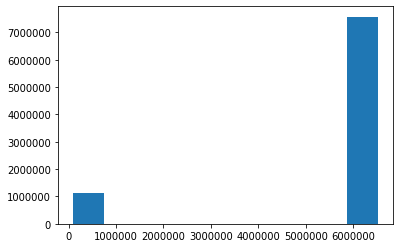

In [16]:
plt.hist(meter_merge.Latitude)
plt.show()

In [17]:
meter_merge = meter_merge[(meter_merge['Latitude'] > 100000)|(meter_merge['Longitude'] > 100000)]

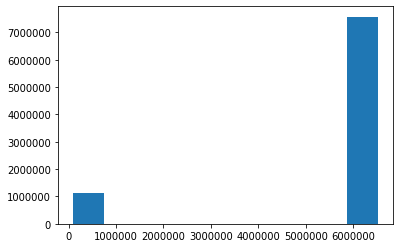

In [18]:
plt.hist(df.Latitude)
plt.show()

In [119]:
# Filter for street cleaning violations
df = df[df['Violation_Description']  == 'NO PARK/STREET CLEAN']
# Fix Issue_Time and add padding zeros so the time can be recognized
df = df[~df.Issue_Time.isna()]
def time_padding(time):
    time = str(int(time))
    return '0'*(4-len(time)) + time
# Apply padding to Issue_time
df['Issue_Time'] = df['Issue_Time'].apply(time_padding)
# Creating combined Datetime column
df['Issue_Date'] = df['Issue_Date'].apply(lambda x: x[:10])
df['Datetime'] = pd.to_datetime(df['Issue_Date'] + ' ' + df['Issue_Time'], format='%m/%d/%Y %H%M')
# Create hour feature
df['Hour'] = df['Datetime'].apply(lambda x: x.hour)
#create day of the week
weekdays=('Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday')
df['Weekday'] = df['Datetime'].apply(lambda x : weekdays[x.weekday()])

In [121]:
df = df.set_index('Datetime')

In [137]:
df['2019':'2020']

,Issue_Date,Issue_Time,Meter ID,Location,Violation_Description,Latitude,Longitude,Hour,Weekday
Datetime,,,,,,,,,
2019-01-02 13:15:00,01/02/2019,1315,NaN,4331 PRICE ST,NO PARK/STREET CLEAN,6.475653e+06,1.862192e+06,13,Wednesday
2019-01-02 13:28:00,01/02/2019,1328,NaN,2000 COMMONWEALTH AVE N,NO PARK/STREET CLEAN,6.475322e+06,1.861696e+06,13,Wednesday
2019-01-02 08:10:00,01/02/2019,0810,NaN,1543 102ND ST E,NO PARK/STREET CLEAN,9.999900e+04,9.999900e+04,8,Wednesday
2019-01-02 08:12:00,01/02/2019,0812,NaN,1543 102ND ST E,NO PARK/STREET CLEAN,9.999900e+04,9.999900e+04,8,Wednesday
2019-01-02 08:13:00,01/02/2019,0813,NaN,1529 102ND ST E,NO PARK/STREET CLEAN,6.486485e+06,1.802191e+06,8,Wednesday
...,...,...,...,...,...,...,...,...,...
2020-06-29 12:39:00,06/29/2020,1239,NaN,5979 BOWCROFT ST,NO PARK/STREET CLEAN,6.446870e+06,1.829611e+06,12,Monday
2020-06-30 08:21:00,06/30/2020,0821,NaN,408 DEL NORTE ST,NO PARK/STREET CLEAN,9.999900e+04,9.999900e+04,8,Tuesday
2020-06-30 11:45:00,06/30/2020,1145,NaN,17000 KINGSBURY ST,NO PARK/STREET CLEAN,6.409905e+06,1.918678e+06,11,Tuesday


In [155]:
df['2020-06']

,Issue_Date,Issue_Time,Meter ID,Location,Violation_Description,Latitude,Longitude,Hour,Weekday
Datetime,,,,,,,,,
2020-06-11 13:07:00,06/11/2020,1307,NaN,12130 MAGNOLIA BL,NO PARK/STREET CLEAN,6.441372e+06,1.882618e+06,13,Thursday
2020-06-11 13:03:00,06/11/2020,1303,NaN,12130 MAGNOLIA BL,NO PARK/STREET CLEAN,6.441372e+06,1.882618e+06,13,Thursday
2020-06-11 12:08:00,06/11/2020,1208,NaN,6712 LANKERSHIM BLVD,NO PARK/STREET CLEAN,6.444401e+06,1.892604e+06,12,Thursday
2020-06-11 11:14:00,06/11/2020,1114,NaN,7920 LANKERSHIM BL,NO PARK/STREET CLEAN,6.444431e+06,1.900683e+06,11,Thursday
2020-06-16 10:41:00,06/16/2020,1041,NaN,6515 SYLMAR AV,NO PARK/STREET CLEAN,6.426628e+06,1.891450e+06,10,Tuesday
...,...,...,...,...,...,...,...,...,...
2020-06-29 12:39:00,06/29/2020,1239,NaN,5979 BOWCROFT ST,NO PARK/STREET CLEAN,6.446870e+06,1.829611e+06,12,Monday
2020-06-30 08:21:00,06/30/2020,0821,NaN,408 DEL NORTE ST,NO PARK/STREET CLEAN,9.999900e+04,9.999900e+04,8,Tuesday
2020-06-30 11:45:00,06/30/2020,1145,NaN,17000 KINGSBURY ST,NO PARK/STREET CLEAN,6.409905e+06,1.918678e+06,11,Tuesday


In [173]:
df['2020-05':].head(100)

,Issue_Date,Issue_Time,Meter ID,Location,Violation_Description,Latitude,Longitude,Hour,Weekday
Datetime,,,,,,,,,
2020-06-11 13:07:00,06/11/2020,1307,NaN,12130 MAGNOLIA BL,NO PARK/STREET CLEAN,6.441372e+06,1.882618e+06,13,Thursday
2020-06-11 13:03:00,06/11/2020,1303,NaN,12130 MAGNOLIA BL,NO PARK/STREET CLEAN,6.441372e+06,1.882618e+06,13,Thursday
2020-06-11 12:08:00,06/11/2020,1208,NaN,6712 LANKERSHIM BLVD,NO PARK/STREET CLEAN,6.444401e+06,1.892604e+06,12,Thursday
2020-06-11 11:14:00,06/11/2020,1114,NaN,7920 LANKERSHIM BL,NO PARK/STREET CLEAN,6.444431e+06,1.900683e+06,11,Thursday
2020-06-16 10:41:00,06/16/2020,1041,NaN,6515 SYLMAR AV,NO PARK/STREET CLEAN,6.426628e+06,1.891450e+06,10,Tuesday
2020-06-17 12:15:00,06/17/2020,1215,NaN,11144 VANOWEN ST,NO PARK/STREET CLEAN,9.999900e+04,9.999900e+04,12,Wednesday
2020-06-18 08:12:00,06/18/2020,0812,NaN,7510 LANKERSHIM BL,NO PARK/STREET CLEAN,9.999900e+04,9.999900e+04,8,Thursday
2020-06-18 10:31:00,06/18/2020,1031,NaN,7814 LANKERSHIM BLVD,NO PARK/STREET CLEAN,6.444428e+06,1.899883e+06,10,Thursday
2020-06-23 11:32:00,06/23/2020,1132,NaN,14423 HAMLIN ST,NO PARK/STREET CLEAN,6.426479e+06,1.891343e+06,11,Tuesday


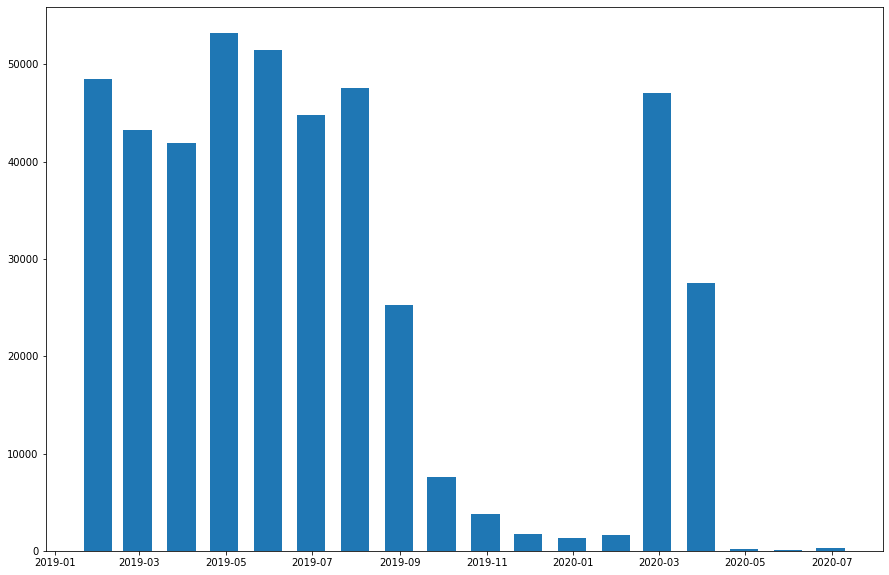

In [144]:
plt.figure(figsize=(15,10))
plt.bar(df['2019':'2020'].resample('M').count().index, df['2019':'2020'].resample('M').count().Violation_Description, width=20)
plt.show()
# plt.savefig('dip.png')

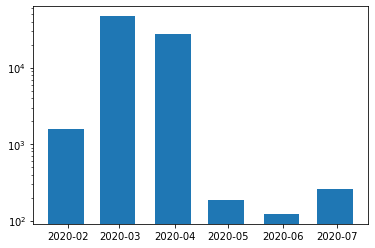

In [156]:
plt.bar(df['2020'].resample('M').count().index, df['2020'].resample('M').count().Violation_Description, width=20)
plt.yscale('log')
plt.show()

In [28]:
# Conversion using pyproj module
inProj = pyproj.Proj({'init': 'epsg:2229'}, preserve_units=True) # make sure unit preserve 
outProj = pyproj.Proj({'init': 'epsg:4326'})
y_1, x_1 = pyproj.transform(inProj, outProj, df["Latitude"].values, df["Longitude"].values)

In [29]:
# Add on the converted coordinates
df["Latitude"] = x_1
df["Longitude"] = y_1
df.head()

,Issue_Date,Issue_Time,Meter ID,Location,Violation_Description,Latitude,Longitude,Datetime,Hour,Weekday
0,2019/09/17,0817,NaN,1324 84TH PL W,NO PARK/STREET CLEAN,33.961646,-118.298938,2019-09-17 08:17:00,8,Tuesday
2,2019/09/17,0809,NaN,1000 85TH ST W,NO PARK/STREET CLEAN,33.960946,-118.291763,2019-09-17 08:09:00,8,Tuesday
3,2019/09/17,0805,NaN,8021 VERMONT AVE,NO PARK/STREET CLEAN,33.966689,-118.291875,2019-09-17 08:05:00,8,Tuesday
16,2019/09/17,1228,NaN,1300 RIVIERA AVE,NO PARK/STREET CLEAN,33.990430,-118.470404,2019-09-17 12:28:00,12,Tuesday
17,2019/09/17,1226,NaN,1203 RIVIERA AVE,NO PARK/STREET CLEAN,33.991083,-118.471020,2019-09-17 12:26:00,12,Tuesday


In [30]:
# Turn citation coordinates into Geopandas geometry column
geometry = [Point(xy) for xy in zip(df.Longitude, df.Latitude)]
crs = {'init': 'epsg:4326'}
geo_df = gpd.GeoDataFrame(df, crs=crs, geometry=geometry)

In [ ]:
geo_df.head()

In [31]:
geo_df = geo_df[['Location', 'Violation_Description', 'Datetime', 'Hour', 'Weekday', 'geometry']]

In [32]:
geo_df.head()

,Location,Violation_Description,Datetime,Hour,Weekday,geometry
0,1324 84TH PL W,NO PARK/STREET CLEAN,2019-09-17 08:17:00,8,Tuesday,POINT (-118.29894 33.96165)
2,1000 85TH ST W,NO PARK/STREET CLEAN,2019-09-17 08:09:00,8,Tuesday,POINT (-118.29176 33.96095)
3,8021 VERMONT AVE,NO PARK/STREET CLEAN,2019-09-17 08:05:00,8,Tuesday,POINT (-118.29188 33.96669)
16,1300 RIVIERA AVE,NO PARK/STREET CLEAN,2019-09-17 12:28:00,12,Tuesday,POINT (-118.47040 33.99043)
17,1203 RIVIERA AVE,NO PARK/STREET CLEAN,2019-09-17 12:26:00,12,Tuesday,POINT (-118.47102 33.99108)


In [33]:
geo_df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 2558681 entries, 0 to 8706369
Data columns (total 6 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Location               object        
 1   Violation_Description  object        
 2   Datetime               datetime64[ns]
 3   Hour                   int64         
 4   Weekday                object        
 5   geometry               geometry      
dtypes: datetime64[ns](1), geometry(1), int64(1), object(3)
memory usage: 136.6+ MB


In [44]:
df.head()

,Issue_Date,Issue_Time,Meter ID,Location,Violation_Description,Latitude,Longitude,Datetime,Hour,Weekday,geometry
0,2019/09/17,0817,NaN,1324 84TH PL W,NO PARK/STREET CLEAN,33.961646,-118.298938,2019-09-17 08:17:00,8,Tuesday,POINT (-118.29894 33.96165)
2,2019/09/17,0809,NaN,1000 85TH ST W,NO PARK/STREET CLEAN,33.960946,-118.291763,2019-09-17 08:09:00,8,Tuesday,POINT (-118.29176 33.96095)
3,2019/09/17,0805,NaN,8021 VERMONT AVE,NO PARK/STREET CLEAN,33.966689,-118.291875,2019-09-17 08:05:00,8,Tuesday,POINT (-118.29188 33.96669)
16,2019/09/17,1228,NaN,1300 RIVIERA AVE,NO PARK/STREET CLEAN,33.990430,-118.470404,2019-09-17 12:28:00,12,Tuesday,POINT (-118.47040 33.99043)
17,2019/09/17,1226,NaN,1203 RIVIERA AVE,NO PARK/STREET CLEAN,33.991083,-118.471020,2019-09-17 12:26:00,12,Tuesday,POINT (-118.47102 33.99108)


In [45]:
df = df.set_index(pd.to_datetime(df.Datetime))

In [167]:
df.head()

,Issue_Date,Issue_Time,Meter ID,Location,Violation_Description,Latitude,Longitude,Hour,Weekday
Datetime,,,,,,,,,
2015-12-28 08:45:00,12/28/2015,0845,NaN,1606 N LAUREL AV,NO PARK/STREET CLEAN,99999.0,99999.0,8,Monday
2015-12-28 08:47:00,12/28/2015,0847,NaN,1620 N LAUREL AV,NO PARK/STREET CLEAN,99999.0,99999.0,8,Monday
2015-12-28 08:48:00,12/28/2015,0848,NaN,1624 N LAUREL AV,NO PARK/STREET CLEAN,99999.0,99999.0,8,Monday
2015-12-28 08:33:00,12/28/2015,0833,NaN,1825 N CHEROKEE AV,NO PARK/STREET CLEAN,99999.0,99999.0,8,Monday
2015-12-28 08:35:00,12/28/2015,0835,NaN,1741 N CHEROKEE AV,NO PARK/STREET CLEAN,6460326.8,1859825.5,8,Monday


In [174]:
df['2020-07']

,Issue_Date,Issue_Time,Meter ID,Location,Violation_Description,Latitude,Longitude,Hour,Weekday
Datetime,,,,,,,,,


In [34]:
# Import steet centerline geometry with Geopandas
st_df = gpd.read_file('Streets_Centerline/Streets_Centerline.shp')

In [35]:
# Function to plot points
def plot_points(latitude, longitude, zoom=0.06, column='Weekday', fsize=20, markersize=10):
    ''' Plots citation data points with streets centered on latitude and longitude.
        
    '''
    bbox = box(longitude - zoom, latitude - zoom,longitude
            + zoom, latitude + zoom)
    f, ax = plt.subplots(1, figsize=(fsize,fsize))
    ax.set_aspect('equal')
    st_df[st_df.geometry.within(bbox)].plot(ax=ax, color='grey', zorder=1)
    geo_df[geo_df.geometry.within(bbox)].plot(ax=ax, column = column, legend=True, zorder=2, markersize=markersize)
    return plt.show()

In [36]:
# Function to plot points
def plot_points_dg(latitude, longitude, zoom=0.06, fsize=20, markersize=10):
    ''' Plots citation data points with streets centered on latitude and longitude.
        
    '''
    bbox = box(longitude - zoom, latitude - zoom,longitude
            + zoom, latitude + zoom)
    f, ax = plt.subplots(1, figsize=(fsize,fsize))
    ax.set_aspect('equal')
    st_df[st_df.geometry.within(bbox)].plot(ax=ax, color='grey', zorder=1)
    geo_dg[geo_dg.geometry.within(bbox)].plot(ax=ax, zorder=2, markersize=markersize)
    return plt.show()

In [ ]:
# Function to plot streets
def plot_streets(latitude, longitude, zoom=0.06, column='Weekday', fsize=20, buffer=0.001, linewidth=2):
    ''' Plots street containing citation attribute data centered on latitude and longitude.
        
    '''
    bbox = box(longitude - zoom, latitude - zoom,longitude
            + zoom, latitude + zoom)
    fil_st_df = st_df[st_df.geometry.within(bbox)]
    fil_cit = geo_df[geo_df.geometry.within(bbox)].copy()
    fil_cit['geometry'] = fil_cit['geometry'].buffer(buffer)
    sjoined = gpd.sjoin(fil_st_df, fil_cit, how='inner', op='intersects')
    # st_df = gpd.read_file('Streets_Centerline/Streets_Centerline.shp', bbox=bbox )
    f, ax = plt.subplots(1, figsize=(fsize,fsize))
    ax.set_aspect('equal')
    fil_st_df.plot(ax=ax, color='grey', zorder=1)
    sjoined.plot(ax=ax, column = column, legend=True, zorder=2, linewidth=linewidth)
    return plt.show()

In [ ]:
plot_points(33.96165, -118.29894, zoom= 0.03)

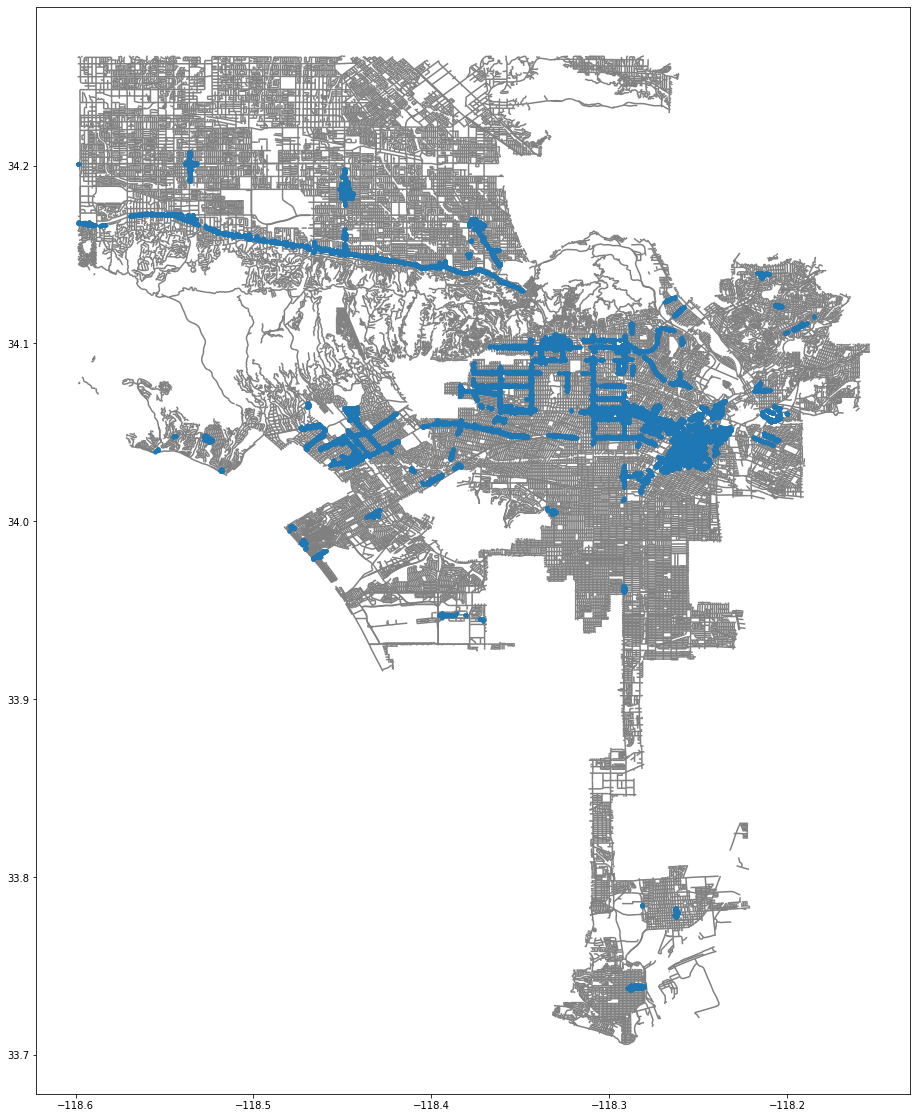

In [78]:
plot_points_dg(33.96165, -118.29894, zoom= 0.3)

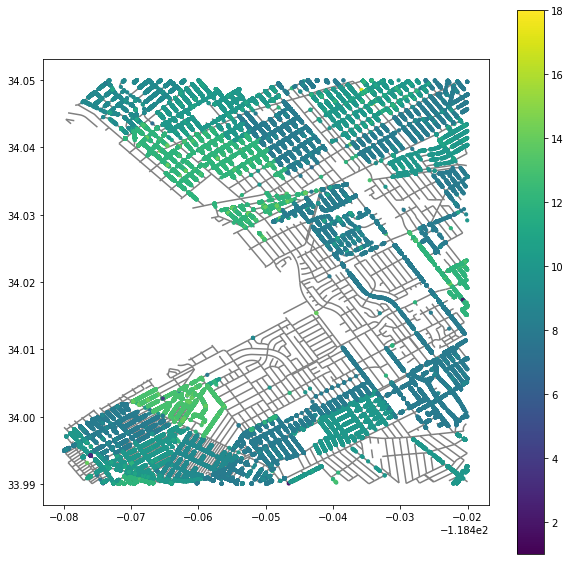

In [29]:
plot_points(34.02, -118.450, column='Hour', zoom=0.03, fsize=10)

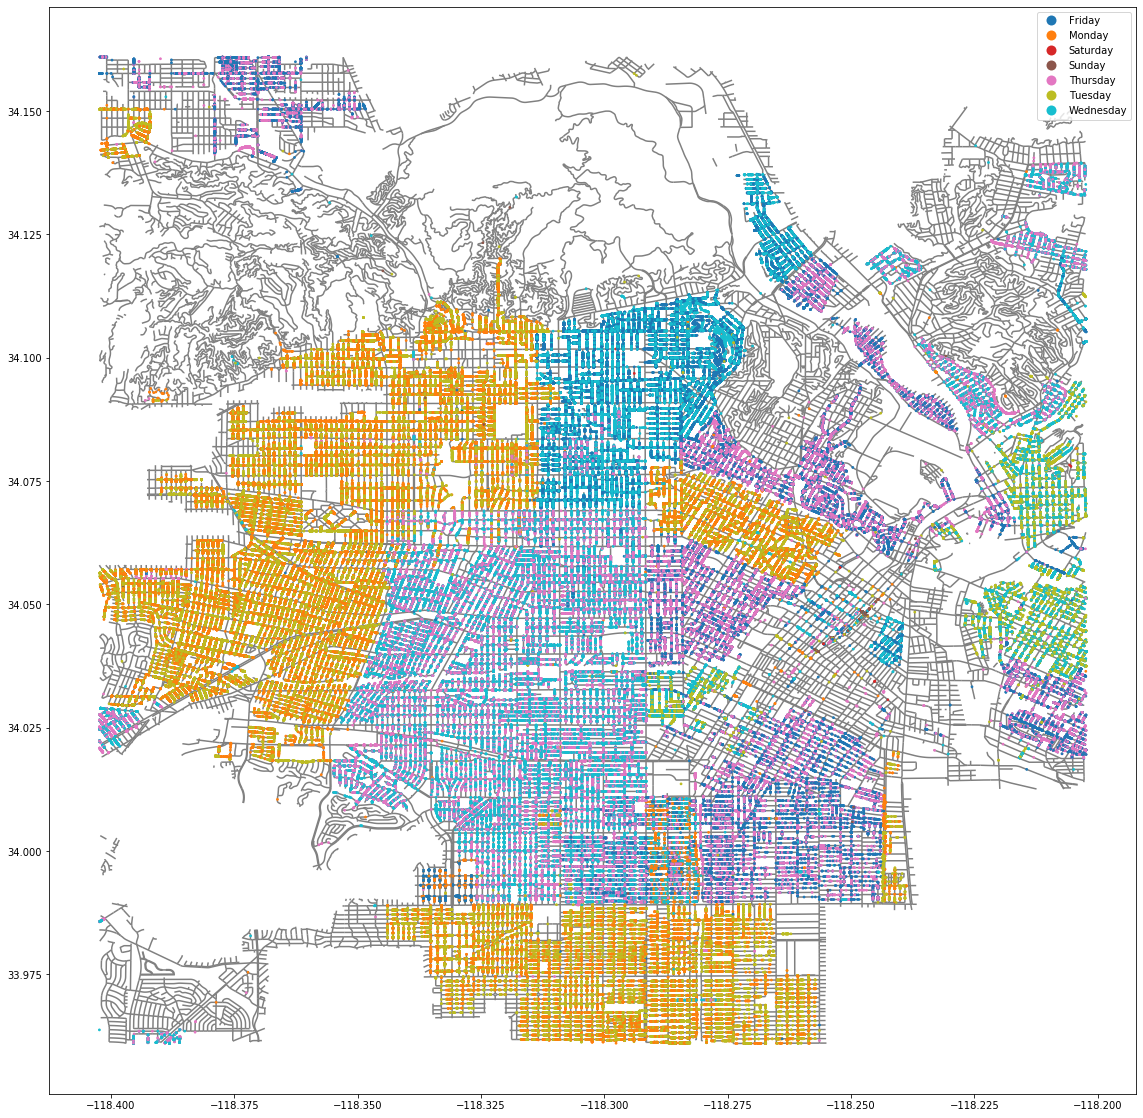

In [28]:
plot_points(34.060988, -118.302358, zoom=0.1, markersize=3)

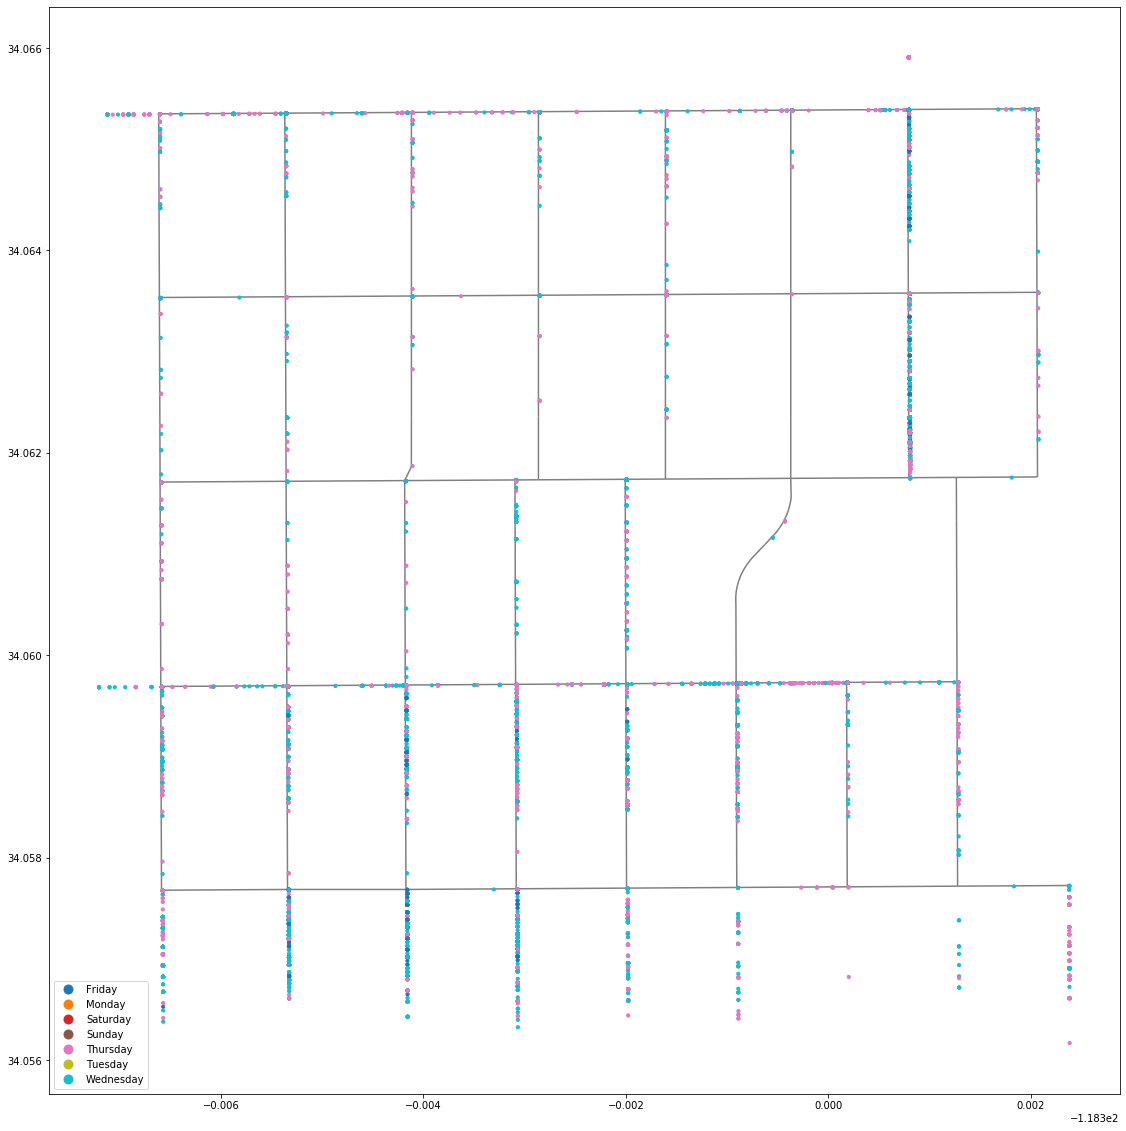

In [36]:
plot_points(34.060988, -118.302358, zoom=0.005)

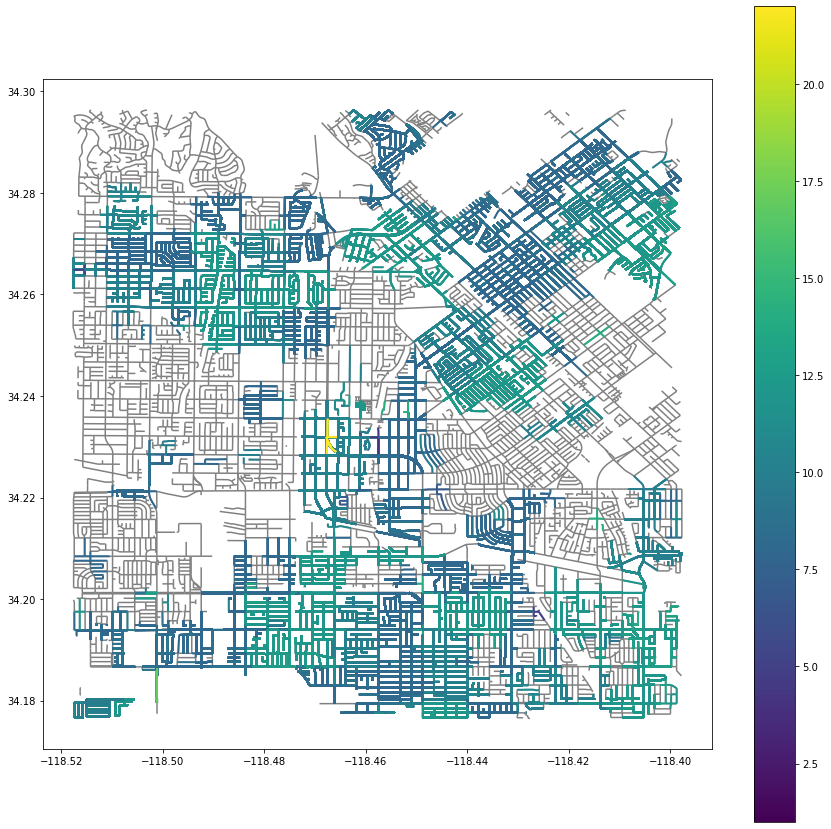

In [29]:
plot_streets(34.2364, -118.4577, fsize=15, column='Hour')

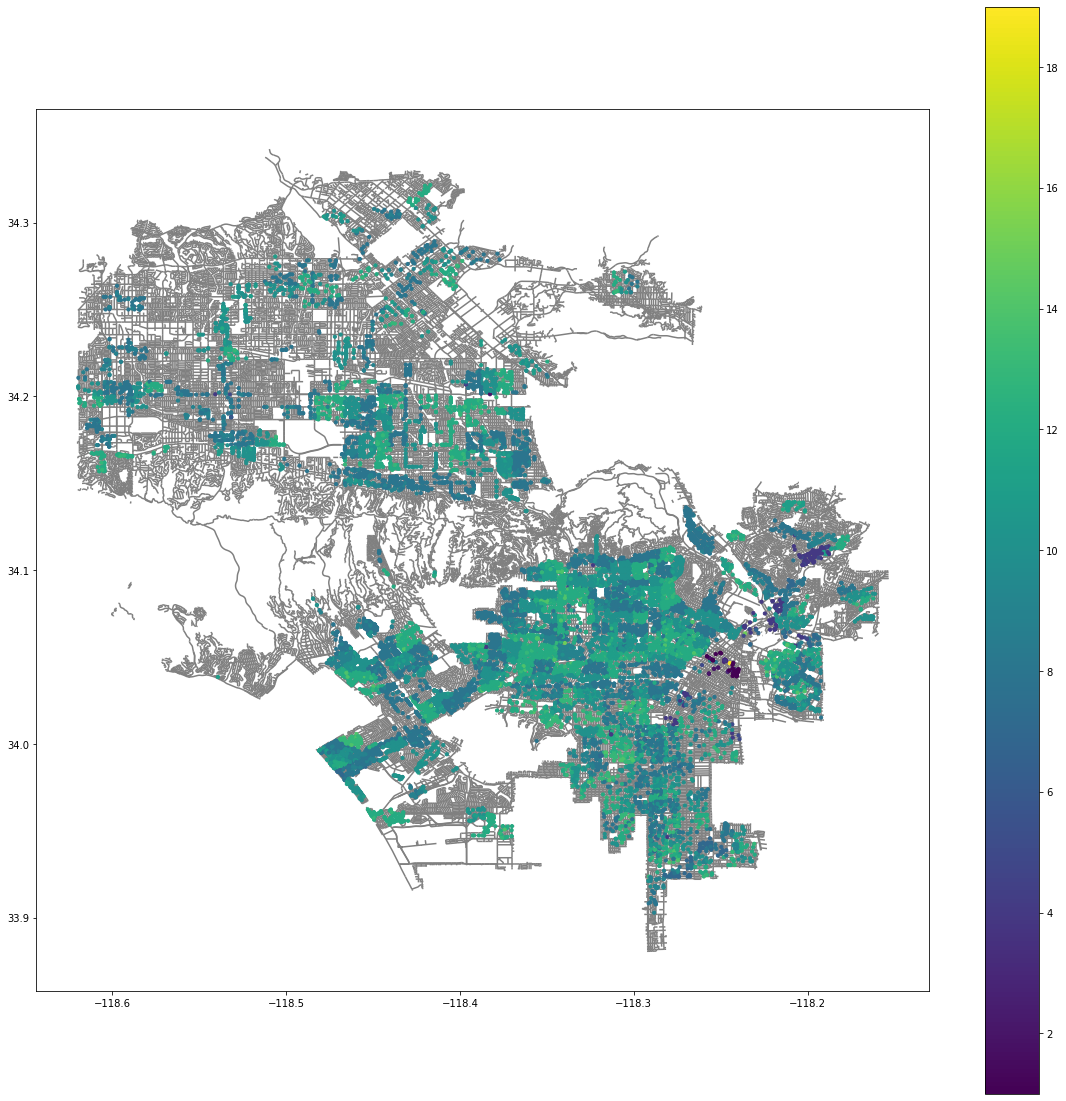

In [64]:
plot_points(34.18, -118.32, zoom=0.3, column='Hour', markersize=10)

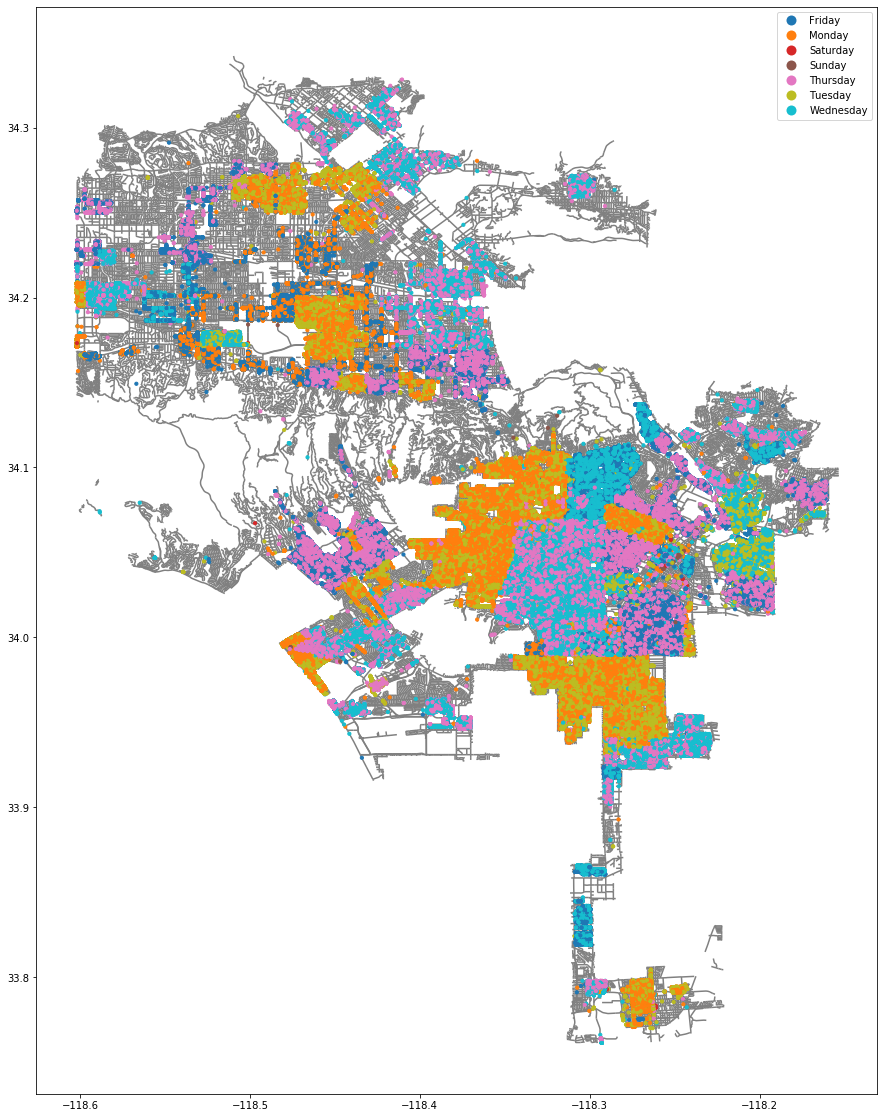

In [22]:
plot_points(34.060988, -118.302358, zoom=0.3)

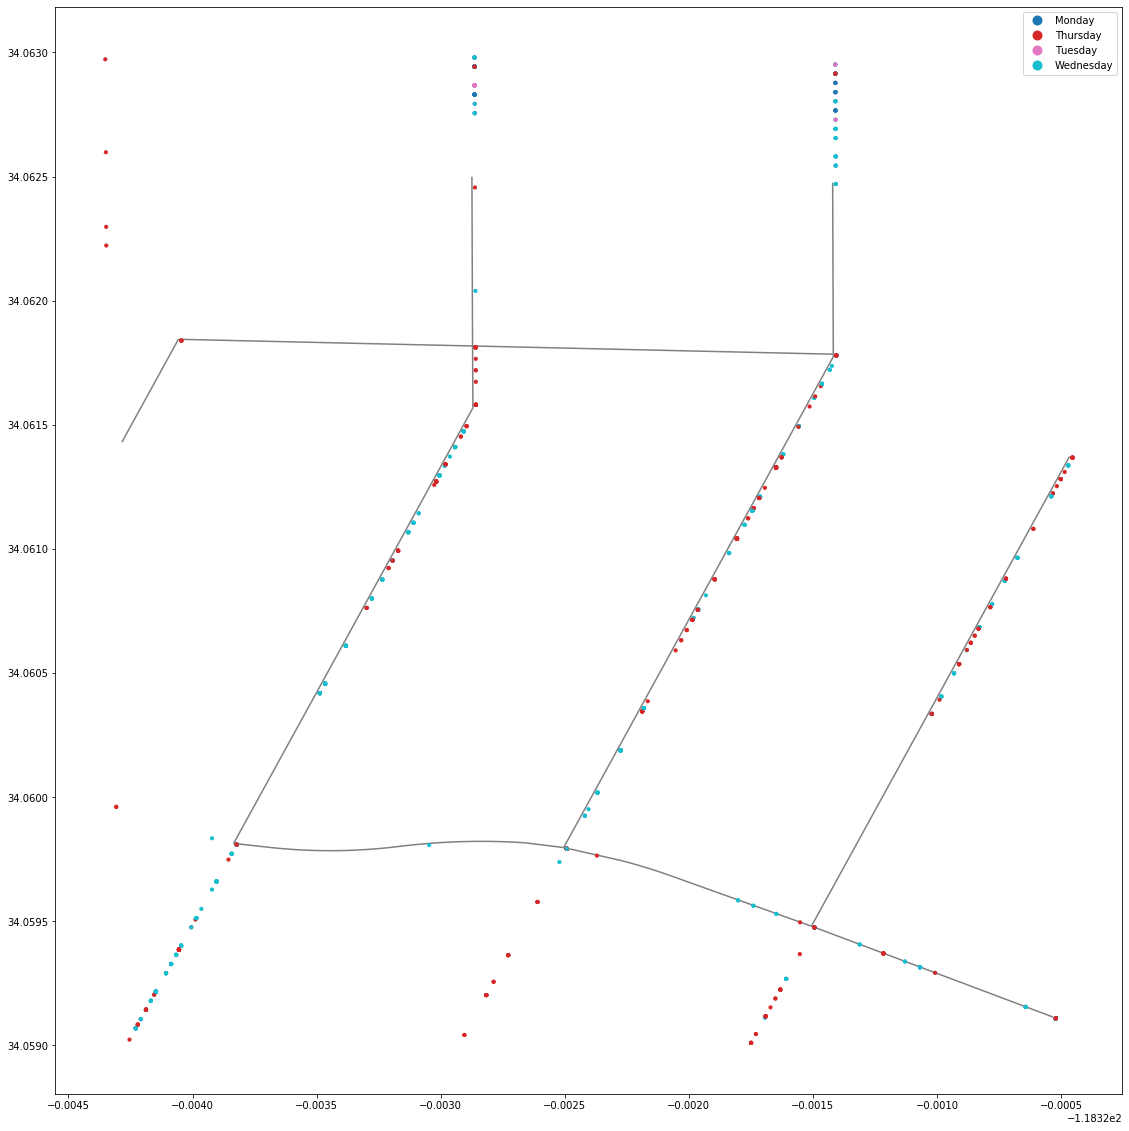

In [27]:
plot_points(34.060988, -118.322358, zoom=0.002)